In [2]:
# itetate over the folders
# to compare and find best arch.
# 1) loss and err curves - total
# 2) extract the average, max, min, etc - total: losses, rel l2 err, linf err

In [3]:
import torch
import os, sys
sys.path.append('/home/antos_j/diploma_sketchbook/PINN/src')

In [4]:
import os
os.listdir()

['seed=13__layers=128_128_128_128__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=13__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=13__layers=64_64_64_64__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=13__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=128_128_128_128__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=42__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=64_64_64_64__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=42__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'manifest.json',
 'summary.json',
 'extract_avrg.ipynb',
 'model_comparison_for_d=4.png',
 '.gitignore',
 'extract_avrg copy.ipynb',
 'model_comparison_for_d=4__.png']

In [5]:
import torch
losses = {}
rel_l2 = {}
linf = {}
for item_path in sorted(os.listdir()):
    if not os.path.isdir(item_path):
        continue
    #print(item_path)
    losses[item_path] = torch.load(f'{item_path}/training_loss.pth')
    rel_l2[item_path] = torch.load(f'{item_path}/training_test_rel_l2.pth')
    linf[item_path] = torch.load(f'{item_path}/training_test_linf.pth')

In [6]:
k = list(linf.keys())[0]
losses[k].keys(), linf[k].keys(), rel_l2[k].keys()

(dict_keys(['total', 'pde', 'ic']),
 dict_keys(['pde', 'ic']),
 dict_keys(['pde', 'ic']))

In [7]:
# add in the total error data - max and avrg
for k in list(linf.keys()):
    rel_l2[k]['total'] = ( torch.tensor(rel_l2[k]['pde']) + torch.tensor(rel_l2[k]['ic']) ) / 2.0
    linf[k]['total'] = torch.tensor([
        linf[k]['pde'],
        linf[k]['ic'],
    ]).max(dim=0).values
k = list(linf.keys())[0]
losses[k].keys(), linf[k].keys(), rel_l2[k].keys()

(dict_keys(['total', 'pde', 'ic']),
 dict_keys(['pde', 'ic', 'total']),
 dict_keys(['pde', 'ic', 'total']))

In [8]:
report_full = {}
for k in list(linf.keys()):
    report = {}
    report["test_rel_l2"] = {}
    report["test_linf"] = {}
    report["loss"] = {}
    #for term in ['pde', 'ic', 'total']:
    for term in ['total']:
        for test_metric, test_data in zip(('test_rel_l2', 'test_linf'), (rel_l2[k], linf[k])):
            last_100 = test_data[term][-100:] if (term == 'total') else torch.tensor(test_data[term])[-100:] 
            report[test_metric][f"{term}_last"] = last_100[-1].item()
            report[test_metric][f"{term}_mean"] = torch.mean(last_100).item()
            report[test_metric][f"{term}_std"] = torch.std(last_100).item()
            report[test_metric][f"{term}_min"] = torch.min(last_100).item()
            report[test_metric][f"{term}_max"] = torch.max(last_100).item()
        last_100 = losses[k][term][-100:]
        report["loss"][f"{term}_last"] = last_100[-1].item()
        report["loss"][f"{term}_mean"] = torch.mean(last_100).item()
        report["loss"][f"{term}_std"] = torch.std(last_100).item()
        report["loss"][f"{term}_min"] = torch.min(last_100).item()
        report["loss"][f"{term}_max"] = torch.max(last_100).item()
    report_full[k] = report

In [9]:
report_full

{'seed=13__layers=128_128_128_128__n_steps=20000__n_steps_decay=800__logging_frequency=40': {'test_rel_l2': {'total_last': 0.012520263902842999,
   'total_mean': 0.0030927888583391905,
   'total_std': 0.0015304444823414087,
   'total_min': 0.0017051748000085354,
   'total_max': 0.012520263902842999},
  'test_linf': {'total_last': 0.01562565565109253,
   'total_mean': 0.005061607342213392,
   'total_std': 0.002086634747684002,
   'total_min': 0.002735421061515808,
   'total_max': 0.01562565565109253},
  'loss': {'total_last': 1.6366916497645434e-06,
   'total_mean': 2.902374376390071e-07,
   'total_std': 2.947026018773613e-07,
   'total_min': 1.2239911484357435e-07,
   'total_max': 1.6366916497645434e-06}},
 'seed=13__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80': {'test_rel_l2': {'total_last': 0.0009870330104604363,
   'total_mean': 0.001705617643892765,
   'total_std': 0.0015975432470440865,
   'total_min': 0.0007492084405384958,
   'total_max': 0.01

In [10]:
list(report_full.keys())

['seed=13__layers=128_128_128_128__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=13__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=13__layers=64_64_64_64__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=13__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=128_128_128_128__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=42__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=64_64_64_64__n_steps=20000__n_steps_decay=800__logging_frequency=40',
 'seed=42__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80']

## The plotting

<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:66: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_123921/1262476977.py:55: SyntaxWarning: invalid escape sequence '\i'
  ax1.barh(y_positions + width/2, df_sorted['linf_mean'], width, label='$L^\infty$')#, color='#d62728')
/tmp/ipykernel_123921/1262476977.py:66: SyntaxWarning: invalid escape sequence '\e'
  ax2.barh(y_positions, df_sorted['loss_mean'], width, label='$\ell_{{total}}$', color='#2ca02c')#, color='#1f77b4')


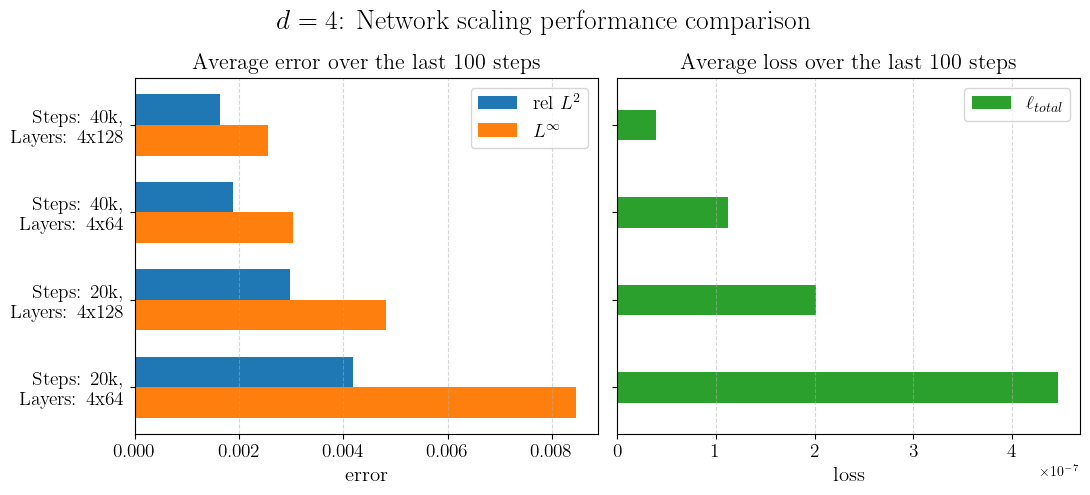

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
# Configure Matplotlib to use LaTeX for text rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

# 1. Parse dictionary into a clean DataFrame
rows = []
processed_configs = []
for key, metrics in report_full.items():
    parts = key.split('__')
    seed = parts[0].split('=')[1]
    n_steps = parts[2].split('=')[1][:-3]+'k'
    layers_str = parts[1].split('=')[1]
    l_split = layers_str.split('_')
    layers = str(len(l_split)) + 'x' + l_split[0]
    #label = f"Layers: {layers}, Steps: {n_steps}"
    label = f"Steps: {n_steps},\nLayers: {layers}"
    if label not in processed_configs:
        rows.append({
            'config': label,
            'rel_l2_mean': metrics['test_rel_l2']['total_mean']/2.0,
            'linf_mean': metrics['test_linf']['total_mean']/2.0,
            'loss_mean': metrics['loss']['total_mean']/2.0,
        })
        processed_configs.append(label)
    else:
        for i in range(len(rows)):
            if rows[i]['config'] == label:
                rows[i]['rel_l2_mean'] += metrics['test_rel_l2']['total_mean']/2.0
                rows[i]['linf_mean'] += metrics['test_linf']['total_mean']/2.0
                rows[i]['loss_mean'] += metrics['loss']['total_mean']/2.0


df = pd.DataFrame(rows)
#df.to_csv('model_comparison.csv', index=False)

# 2. Sort by the best final step relative L2 error (ascending)
df_sorted = df.sort_values(by='rel_l2_mean', ascending=True)

y_positions = np.arange(len(df_sorted))
width = 0.35

# 3. Create a Detailed 2-Panel Plot (Last vs Mean Performance)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# Left Panel: Average Errors
ax1.barh(y_positions - width/2, df_sorted['rel_l2_mean'], width, label='rel $L^2$')#, color='#2ca02c'
ax1.barh(y_positions + width/2, df_sorted['linf_mean'], width, label='$L^\infty$')#, color='#d62728')
ax1.set_yticks(y_positions)
ax1.set_yticklabels(df_sorted['config'], fontsize=14)
ax1.invert_yaxis()  # Puts the best model at the top
ax1.set_xlabel('error', fontsize=15)
ax1.tick_params(axis='x', labelsize=14)
ax1.set_title('Average error over the last 100 steps', fontsize=16)
ax1.legend(fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Right Panel: Average losses
ax2.barh(y_positions, df_sorted['loss_mean'], width, label='$\ell_{{total}}$', color='#2ca02c')#, color='#1f77b4')
#ax2.barh(y_positions + width/2, df_sorted['linf_last'], width, label='$L^\infty$')#, color='#ff7f0e')
ax2.tick_params(axis='x', labelsize=14)
ax2.set_xlabel('loss', fontsize=15)
ax2.set_title('Average loss over the last 100 steps', fontsize=16)
ax2.legend(fontsize=14)
ax2.grid(axis='x', linestyle='--', alpha=0.5)


plt.suptitle('$d=4$: Network scaling performance comparison', fontsize=20, weight='bold')
plt.tight_layout()
plt.savefig('nn_scaling_comparison_d=4.png', dpi=400)
plt.show()
plt.close()

In [12]:
[k for k in list(report_full.keys()) if '40000' in k]

['seed=13__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=13__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
 'seed=42__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80']

In [13]:
largerNet = [
    'seed=13__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
    'seed=42__layers=128_128_128_128__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
]
smallerNet = [
    'seed=13__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80',
    'seed=42__layers=64_64_64_64__n_steps=40000__n_steps_decay=1600__logging_frequency=80'
]

In [14]:
for net in [largerNet, smallerNet]:
    rel_l2 = 0.0
    linf = 0.0
    loss = 0.0
    for k in net:
        rel_l2 += report_full[k]['test_rel_l2']['total_mean']
        linf += report_full[k]['test_linf']['total_mean']
        loss += report_full[k]['loss']['total_mean']
    rel_l2 /= 2.0
    linf /= 2.0
    loss /= 2.0
    print(loss, rel_l2, linf)

3.8799088386554104e-08 0.0016248409519903362 0.002547697746194899
1.1255963272560621e-07 0.0018881353316828609 0.0030373253393918276
